# KV Bench — Stratigraphic Strategy Benchmark (Modal)

Benchmarking Stratigraphic KV-cache compression against existing strategies (H2O, SnapKV, uniform quantization) on Llama-3.2-1B using Modal GPUs.

WikiText-2 perplexity as quality metric, analytical memory estimates for compression.

## Setup

In [ ]:
%uv pip install -q flash-linear-attention transformers datasets accelerate matplotlib tqdm

import os
if not os.path.exists('PROJECT'):
    !GIT_SSL_NO_VERIFY=1 git clone https://gitlab.cim.rhul.ac.uk/wmis066/PROJECT.git PROJECT
%cd PROJECT
!GIT_SSL_NO_VERIFY=1 git pull origin main
%uv pip install -e .

from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

import torch, logging
logging.basicConfig(level=logging.INFO)

print(f"PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}, VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.cuda.reset_peak_memory_stats()

MODEL = "meta-llama/Llama-3.2-1B-Instruct"
print(f"Model: {MODEL}")

## Smoke test

Quick sanity check with 10 samples, short windows.

In [2]:
!python -m kv_bench \
    --model {MODEL} \
    --strategies baseline stratigraphic \
    --max-samples 10 \
    --max-seq-len 512 \
    -v

2026-03-23 20:37:13,211 [INFO] kv_bench.device_config: Detected GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
2026-03-23 20:37:13,212 [INFO] kv_bench.device_config: Config: batch_size=2, max_seq_len=4096, stride=1024, dtype=torch.bfloat16
2026-03-23 20:37:30,284 [INFO] kv_bench.runner: Loading model: meta-llama/Llama-3.2-1B-Instruct
2026-03-23 20:37:30,291 [DEBUG] urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443
2026-03-23 20:37:30,471 [DEBUG] urllib3.connectionpool: https://huggingface.co:443 "HEAD /meta-llama/Llama-3.2-1B-Instruct/resolve/main/config.json HTTP/1.1" 200 0
2026-03-23 20:37:30,476 [DEBUG] filelock: Attempting to acquire lock 47528931433776 on /root/.cache/huggingface/hub/.locks/models--meta-llama--Llama-3.2-1B-Instruct/3e3aaf51a035cb5092d9f6827a0dc074657ba88c.lock
2026-03-23 20:37:30,477 [DEBUG] filelock: Lock 47528931433776 acquired on /root/.cache/huggingface/hub/.locks/models--meta-llama--Llama-3.2-1B-Instruct/3e3aaf51a035cb5092d9f6827a0dc074657ba

!python -m kv_bench \
    --model {MODEL} \
    --strategies baseline stratigraphic stratigraphic-quant int8 int4 h2o snapkv adaptive \
    --max-samples 100 \
    --max-seq-len 1024 \
    --stride 512 \
    --output results_all.json \
    --markdown results_all.md \
    -v

In [3]:
!python -m kv_bench \
    --model {MODEL} \
    --strategies baseline stratigraphic adaptive int8 int4 h2o snapkv \
    --output results_all.json \
    --markdown results_all.md \
    -v

2026-03-23 20:38:27,022 [INFO] kv_bench.device_config: Detected GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
2026-03-23 20:38:27,023 [INFO] kv_bench.device_config: Config: batch_size=2, max_seq_len=4096, stride=1024, dtype=torch.bfloat16
2026-03-23 20:38:34,100 [INFO] kv_bench.runner: Loading model: meta-llama/Llama-3.2-1B-Instruct
2026-03-23 20:38:34,103 [DEBUG] urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443
2026-03-23 20:38:34,280 [DEBUG] urllib3.connectionpool: https://huggingface.co:443 "HEAD /meta-llama/Llama-3.2-1B-Instruct/resolve/main/config.json HTTP/1.1" 200 0
2026-03-23 20:38:34,291 [INFO] kv_bench.runner: Forcing eager attention (strategies need attention weights)
2026-03-23 20:38:34,399 [DEBUG] urllib3.connectionpool: https://huggingface.co:443 "HEAD /meta-llama/Llama-3.2-1B-Instruct/resolve/main/tokenizer_config.json HTTP/1.1" 200 0
2026-03-23 20:38:34,510 [DEBUG] urllib3.connectionpool: https://huggingface.co:443 "GET /api/models/meta-llama/Llama-3

## Results

INFO:matplotlib.font_manager:generated new fontManager


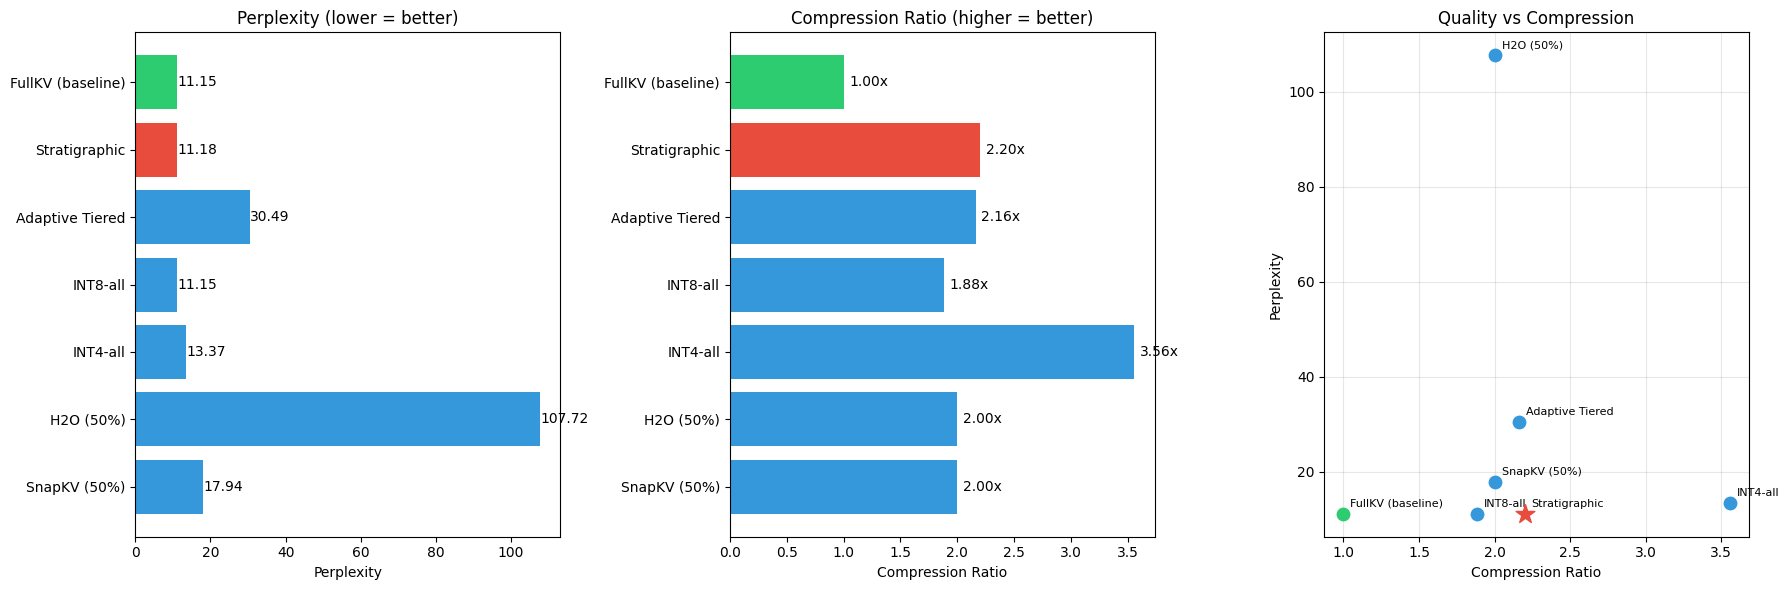

In [4]:
import json
import matplotlib.pyplot as plt

results_file = 'results_all.json' if os.path.exists('results_all.json') else 'results_stratigraphic.json'
with open(results_file) as f:
    raw = json.load(f)

results = raw['results'] if isinstance(raw, dict) and 'results' in raw else raw

names = [r['name'] for r in results]
ppls = [r['perplexity'] for r in results]
compressions = [r['compression_ratio'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['#2ecc71' if 'baseline' in n.lower() else '#e74c3c' if 'strat' in n.lower() else '#3498db' for n in names]

axes[0].barh(names, ppls, color=colors)
axes[0].set_xlabel('Perplexity')
axes[0].set_title('Perplexity (lower = better)')
axes[0].invert_yaxis()
for i, v in enumerate(ppls):
    axes[0].text(v + 0.1, i, f'{v:.2f}', va='center')

axes[1].barh(names, compressions, color=colors)
axes[1].set_xlabel('Compression Ratio')
axes[1].set_title('Compression Ratio (higher = better)')
axes[1].invert_yaxis()
for i, v in enumerate(compressions):
    axes[1].text(v + 0.05, i, f'{v:.2f}x', va='center')

for i, name in enumerate(names):
    m = '*' if 'strat' in name.lower() else 'o'
    s = 200 if 'strat' in name.lower() else 80
    axes[2].scatter(compressions[i], ppls[i], s=s, marker=m, color=colors[i], zorder=5)
    axes[2].annotate(name, (compressions[i], ppls[i]), textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[2].set_xlabel('Compression Ratio')
axes[2].set_ylabel('Perplexity')
axes[2].set_title('Quality vs Compression')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kv_bench_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-layer zone distribution

Llama-3.2-1B: 16 layers, 32 Q heads, 8 KV heads, head_dim=64.

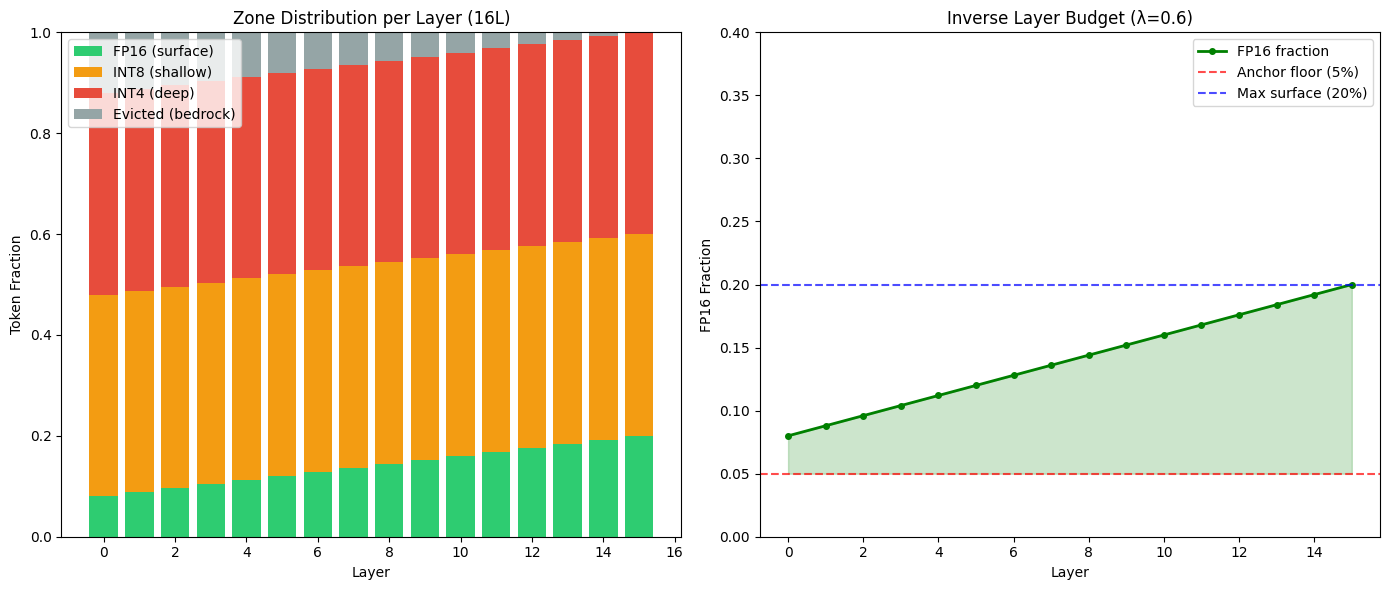

seq_len= 1024: Full KV=   32.0 MB  Stratigraphic=   14.5 MB  2.20x
seq_len= 2048: Full KV=   64.0 MB  Stratigraphic=   29.1 MB  2.20x
seq_len= 4096: Full KV=  128.0 MB  Stratigraphic=   58.2 MB  2.20x
seq_len= 8192: Full KV=  256.0 MB  Stratigraphic=  116.5 MB  2.20x


In [5]:
from streaming_attention.stratigraphic import StratigraphicConfig
import numpy as np

config = StratigraphicConfig()
num_layers, num_heads, num_kv_heads, hidden_size, head_dim = 16, 32, 8, 2048, 64

layers = np.arange(num_layers)
fp16_fracs = [config.zone_surface * ((1 - config.lambda_) + config.lambda_ * l / (num_layers - 1)) for l in layers]
int8_fracs = [config.zone_shallow] * num_layers
int4_fracs = [config.zone_deep] * num_layers
evict_fracs = [1.0 - fp16 - config.zone_shallow - config.zone_deep for fp16 in fp16_fracs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(layers, fp16_fracs, label='FP16 (surface)', color='#2ecc71')
ax1.bar(layers, int8_fracs, bottom=fp16_fracs, label='INT8 (shallow)', color='#f39c12')
bottoms2 = [fp16 + int8 for fp16, int8 in zip(fp16_fracs, int8_fracs)]
ax1.bar(layers, int4_fracs, bottom=bottoms2, label='INT4 (deep)', color='#e74c3c')
bottoms3 = [b + int4 for b, int4 in zip(bottoms2, int4_fracs)]
ax1.bar(layers, evict_fracs, bottom=bottoms3, label='Evicted (bedrock)', color='#95a5a6')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Token Fraction')
ax1.set_title('Zone Distribution per Layer (16L)')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 1.0)

ax2.plot(layers, fp16_fracs, 'g-o', markersize=4, linewidth=2, label='FP16 fraction')
ax2.axhline(y=config.anchor_budget, color='red', linestyle='--', alpha=0.7, label=f'Anchor floor ({config.anchor_budget:.0%})')
ax2.axhline(y=config.zone_surface, color='blue', linestyle='--', alpha=0.7, label=f'Max surface ({config.zone_surface:.0%})')
ax2.fill_between(layers, config.anchor_budget, fp16_fracs, alpha=0.2, color='green')
ax2.set_xlabel('Layer')
ax2.set_ylabel('FP16 Fraction')
ax2.set_title(f'Inverse Layer Budget (λ={config.lambda_})')
ax2.legend()
ax2.set_ylim(0, 0.4)

plt.tight_layout()
plt.savefig('stratigraphic_layers.png', dpi=150, bbox_inches='tight')
plt.show()

# memory breakdown
from kv_bench.strategies.stratigraphic import StratigraphicStrategy
from kv_bench.strategies.baseline import FullKVBaseline
from types import SimpleNamespace

mock_config = SimpleNamespace(
    num_hidden_layers=num_layers, num_attention_heads=num_heads,
    num_key_value_heads=num_kv_heads, hidden_size=hidden_size
)

strat = StratigraphicStrategy()
baseline_strat = FullKVBaseline()

for sl in [1024, 2048, 4096, 8192]:
    full_mb = baseline_strat.memory_bytes(sl, mock_config) / (1024**2)
    strat_mb = strat.memory_bytes(sl, mock_config) / (1024**2)
    ratio = full_mb / strat_mb
    print(f'seq_len={sl:5d}: Full KV={full_mb:7.1f} MB  Stratigraphic={strat_mb:7.1f} MB  {ratio:.2f}x')

## Results table

In [6]:
# Print markdown results if available
for md_file in ['results_stratigraphic.md', 'results_all.md']:
    if os.path.exists(md_file):
        print(f'\n=== {md_file} ===')
        with open(md_file) as f:
            print(f.read())


=== results_all.md ===
# KV Cache Strategy Benchmark Results

| Strategy | PPL | ΔPPL | Mem MB | Comp. | Prefill ms |
|----------|-----|------|--------|-------|------------|
| FullKV (baseline) | 11.15 | — | 128.0 | 1.0x | 64.5 |
| Stratigraphic | 11.18 | +0.04 | 58.2 | 2.2x | 1529.2 |
| Adaptive Tiered | 30.49 | +19.35 | 59.2 | 2.2x | 1026.9 |
| INT8-all | 11.15 | +0.00 | 68.0 | 1.9x | 833.9 |
| INT4-all | 13.37 | +2.22 | 36.0 | 3.6x | 749.2 |
| H2O (50%) | 107.72 | +96.57 | 64.0 | 2.0x | 459.4 |
| SnapKV (50%) | 17.94 | +6.79 | 64.0 | 2.0x | 448.3 |

